In [1]:
#Motivation :
# Solar flares are explosive releases of magnetic energy. 
#To predict them effectively, we must respect the underlying physics. 
#Our Aditya-L1 payloads are complementary: SoLEXS measures gradual thermal heating (Soft X-rays), while HEL1OS measures impulsive non-thermal electron acceleration (Hard X-rays). 

#Neupert Effect :
# According to the Neupert Effect, the rate of change of Soft X-rays is proportional to the Hard X-rays ($dS/dt \propto H$).
#NC²AN operationalizes this physical law using Cross-Attention, rather than treating the sun as a generic time-series black-box.


#  Notebook 1 : 
# In this notebook, we build the production-grade Data Engineering pipeline:
# 1. Parsing real Aditya-L1 FITS files (SoLEXS + HEL1OS).
# 2. Validating data integrity and detecting fill values.
# 3. Filtering invalid periods via GTI (Good Time Intervals) from both payloads.
# 4. Synchronizing timestamps via nearest-neighbor join (both payloads are ~1Hz).
# 5. Cleaning cosmic ray anomalies via Hampel Filter.
# 6. Engineering the HOPE Physics Features.
# 7. Constructing the final batched TensorFlow `tf.data.Dataset`s.


#  Expected Output
# Clean, aligned, physically-augmented tensor streams packaged into TensorFlow datasets ready for the Keras Cross-Attention network.

In [2]:
import os 
import glob # Search files using patterns 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf
from sklearn.preprocessing import RobustScaler #To handle the outliers 
from scipy.signal import savgol_filter #Savitzky-Golay smoothning for derivatives calculation 
from astropy.io import fits #Read fits file 
from astropy.time import Time 

2026-06-24 12:27:27.694976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782304047.721793    2271 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782304047.730160    2271 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782304047.752077    2271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782304047.752111    2271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782304047.752114    2271 computation_placer.cc:177] computation placer alr

In [3]:
#Setting the plot styling :
plt.style.use('dark_background')
np.random.seed(42)
tf.random.set_seed(42)


In [4]:
#NC2AN Configuration Flags :

HELIOS_MODE= 'A' # Means which HEL1OS broadband channel should be loaded 
# Mode A = 1.8-90 keV Broadband
#This is a broadband so it will be covering all the energies band ...
# The Neupert Effect relates the derivative of soft X-ray emission to total non-thermal hard X-ray energy deposition 
#The broadband 1.8-90 keV channel is the closest observvable proxy to total injected electron energy 
USE_SIMULATED_DATA= False 
DATA_DIR= "/kaggle/input/datasets/tamish03/isro-nc2an-dataset"


#Summary :
#Magnetic field lines become highly stressed and twisted
#↓
#Magnetic reconnection occurs
#↓
#Stored magnetic energy is suddenly released
#↓
#Large populations of electrons are accelerated to high energies
#↓
#These electrons travel downward into the denser solar atmosphere
#↓
#Their collisions produce Hard X-rays (HEL1OS observes these)
#↓
#The deposited energy heats the surrounding plasma
#↓
#The heated plasma emits Soft X-rays (SoLEXS observes these)



#Hard X-rays are NOT the energy itself.
    
#Hard X-rays are an observable proxy for the rate at which
#energetic electrons are depositing energy into the plasma.
                                   
#More Hard X-rays
#⇒ More electron energy deposition
#⇒ More plasma heating
#⇒ Stronger increase in Soft X-rays


# Why only 1.8- 90 keV broadband ?
#Ans : The Neupert Effect depends on total non-thermal energy deposition rather than individual spectral components. The HEL1OS 1.8–90 keV broadband channel already captures the integrated hard X-ray emission and therefore serves as the most direct proxy for total electron energy injection while keeping the pipeline simple, robust, and computationally efficient.

In [5]:
#Data Loading :

# Aditya-L1 data arrives in FITS format. SoLEXS provides `TIME` (Unix Epoch) and `COUNTS`.
# HEL1OS provides `MJD`, `ISOT`, `CTR` (count rate), and `STAT_ERR` across 5 energy bands
# (5-20, 20-30, 30-40, 40-60, 1.8-90 keV). Both payloads operate at ~1Hz cadence.

# It automatically discovers the SoLEXS and HEL1OS files 
def discover_fits_files(data_dir):
    solexs_files = sorted(
        glob.glob(os.path.join(data_dir, 'AL1_SOLEXS_*_L1.lc')) +
        glob.glob(os.path.join(data_dir, '*solexs*.lc')) +
        glob.glob(os.path.join(data_dir, '*SOLEXS*.fits'))
    )
    helios_files = sorted(
        glob.glob(
        os.path.join(
            data_dir,
            'lightcurve_cdte*.fits'
        )
    )
)
#Summary :
# "Search the Kaggle dataset folder and automatically find every SoLEXS lightcurve (.lc) file regardless of date."

#Now Destroying the Dublicate :
    solexs_files = sorted(set(solexs_files))
    helios_files = sorted(set(helios_files))
    
    print(f"  Discovered {len(solexs_files)} SoLEXS file(s): {[os.path.basename(f) for f in solexs_files]}")
    print(f"  Discovered {len(helios_files)} HEL1OS file(s): {[os.path.basename(f) for f in helios_files]}")
    return solexs_files, helios_files

    

In [6]:
# Lets load the SoLEXS data : 
def load_solexs(filepath):
    with fits.open(filepath) as hdul:
        data = hdul[1].data # here it contains time_unix and its counts 
        time_unix = np.array(data['TIME'], dtype=np.float64)
        counts = np.array(data['COUNTS'], dtype=np.float64)
    return time_unix, counts

#Summary :

#Time_unix: At what second did SoLEXS observe ? 
#Counts : How much Soft-XRay emission was detected at that second 

# The SoLEXS is looking at the Sun and asking every second :
#How much Soft X-Ray energy is coming from the Sun right now as in the form of counts ? 

#here counts is ultimately our Soft-XRay plasma response signal which will 
#Become our target value for prediction ...

#Conclusion : 
#"For every second of observation, tell me when SoLEXS observed the Sun and how much Soft X-Ray emission it measured at that moment."


    

In [7]:
# When did HEL1OS observe ?
# How much hard X-Ray was observed?
# How uncertain is that measurement?

# HEL1OS counts rise -> leads to SOLEXS counts rise...
# Hard X-Ray acts as a proxy for injected electron energy.

def load_helios(filepath, band='1.8-90'):

    # In our data files:
    # HDU1 -> 5-20 keV
    # HDU2 -> 20-30 keV
    # HDU3 -> 30-40 keV
    # HDU4 -> 40-60 keV
    # HDU5 -> 1.8-90 keV (Broadband)


    # Mapping key-value pairs of our energy bands
    band_hdu_map = {
        '5-20':   1,
        '20-30':  2,
        '30-40':  3,
        '40-60':  4,
        '1.8-90': 5
    }

    with fits.open(filepath) as hdul:

        # Total number of HDUs present inside the FITS file
        n_hdus = len(hdul)

        # Suppose we want all bands later
        if band == 'ALL':

            all_ctr = []
            all_err = []

            # Loop through every energy band
            for band_name, hdu_idx in band_hdu_map.items():

                # Defensive safety check
                if hdu_idx >= n_hdus:
                    raise ValueError(
                        f"HEL1OS FITS has only {n_hdus} HDUs but band '{band_name}' "
                        f"requires HDU {hdu_idx}. File may be truncated."
                    )

                d = hdul[hdu_idx].data

                # Extract count rates
                all_ctr.append(
                    np.array(
                        d['CTR'],
                        dtype=np.float64
                    )
                )

                # Extract statistical errors
                all_err.append(
                    np.array(
                        d['STAT_ERR'],
                        dtype=np.float64
                    )
                )

            # Shape becomes [N, 5]
            # Each column corresponds to one energy band
            ctr = np.column_stack(all_ctr)
            stat_err = np.column_stack(all_err)

            # All HEL1OS bands share the same timestamps
            # We can safely use HDU1's MJD column
            mjd = np.array(
                hdul[1].data['MJD'],
                dtype=np.float64
            )

        else:

            # Validate requested band
            if band not in band_hdu_map:
                raise ValueError(
                    f"Unknown band '{band}'. "
                    f"Valid: {list(band_hdu_map.keys())}"
                )

            # Find corresponding HDU
            hdu_idx = band_hdu_map[band]

            # Safety check against corrupted files
            if hdu_idx >= n_hdus:
                raise ValueError(
                    f"HEL1OS FITS has only {n_hdus} HDUs but band '{band}' "
                    f"requires HDU {hdu_idx}. File may be truncated."
                )

            # Load selected energy band
            data = hdul[hdu_idx].data

            # Extract timestamps
            mjd = np.array(
                data['MJD'],
                dtype=np.float64
            )

            # Extract hard X-ray count rates
            ctr = np.array(
                data['CTR'],
                dtype=np.float64
            )

            # Extract uncertainty estimates
            stat_err = np.array(
                data['STAT_ERR'],
                dtype=np.float64
            )

        # HEL1OS stores time as Modified Julian Date (MJD)
        # Convert to Unix Epoch so that it matches SoLEXS timestamps
        time_unix = Time(
            mjd,
            format='mjd'
        ).unix

    return time_unix, ctr, stat_err

In [8]:
# GTI : Good Time Interval
# Think like satellite is observing the data but not every second is scientific usable
# Some may detect calibration ,Instrument reset ,Detector glitches

# It returns:
# gti_starts: Start time of valid science intervals
# gti_stops: Stop time of valid science intervals
# If no gti founds return None,None

def load_gti(filepath):

    # Common GTI extension names found in FITS files
    GTI_KEYWORDS = [
        'GTI',
        'STDGTI',
        'GOOD_TIME_INTERVAL',
        'GTI_EXT'
    ]

    with fits.open(filepath) as hdul:

        # Iterate through every HDU and search for a GTI table
        for hdu in hdul:

            hdu_name = getattr(
                hdu,
                'name',
                ''
            ).upper()

            # Match exact names OR any HDU name containing GTI
            if hdu_name in GTI_KEYWORDS or 'GTI' in hdu_name:

                try:

                    # Skip HDUs that do not contain tabular data
                    if hdu.data is None:
                        continue

                    # Available column names in current GTI table
                    col_names = [
                        c.upper()
                        for c in hdu.data.names
                    ]

               
                    # CASE 1 : SoLEXS style GTI
                    # Columns = START / STOP
                    # Times already stored as Unix Epoch seconds
                   
                    if (
                        'START' in col_names
                        and
                        'STOP' in col_names
                    ):

                        gti_starts = np.array(
                            hdu.data['START'],
                            dtype=np.float64
                        )

                        gti_stops = np.array(
                            hdu.data['STOP'],
                            dtype=np.float64
                        )

                   
                    # CASE 2 : HEL1OS style GTI
                    # Columns = tstart / tstop
                    # Times stored in MJD
                    # Must convert MJD → Unix Epoch
                   
                    elif (
                        'TSTART' in col_names
                        and
                        'TSTOP' in col_names
                    ):

                        # Preserve original column names
                        column_map = {
                            c.upper(): c
                            for c in hdu.data.names
                        }

                        tstart_mjd = np.array(
                            hdu.data[
                                column_map['TSTART']
                            ],
                            dtype=np.float64
                        )

                        tstop_mjd = np.array(
                            hdu.data[
                                column_map['TSTOP']
                            ],
                            dtype=np.float64
                        )

                        # Convert MJD → Unix Epoch seconds
                        gti_starts = Time(
                            tstart_mjd,
                            format='mjd'
                        ).unix

                        gti_stops = Time(
                            tstop_mjd,
                            format='mjd'
                        ).unix

                    else:

                        # GTI-like extension but unsupported columns
                        continue

                    print(
                        f"  Found GTI extension: '{hdu.name}' "
                        f"with {len(gti_starts)} interval(s)"
                    )

                    return gti_starts, gti_stops

                except Exception as e:

                    print(
                        f"  WARNING: Failed to parse GTI "
                        f"extension '{hdu_name}': {e}"
                    )

                    continue

    # No GTI extension found
    # Notebook 1 freeze decision:
    # Assume entire observation is valid.
    print(
        "  WARNING: No GTI extension found. "
        "Assuming all data is valid."
    )

    return None, None

In [9]:
# Overalapping check :
# Do i actally have a SoLEXS and HEL1OS file that observed the Sun during the same time period
# This is for the synchronization

def discover_overlap_pairs(solexs_files, helios_files):

    # Stores the largest overlap found so far (in seconds)
    best_overlap = 0

    # Stores the corresponding file pair
    best_pair = (None, None)

    # Check every SoLEXS file
    for sf in solexs_files:

        s_time, _ = load_solexs(sf)

        # Observation start and end time for SoLEXS
        s_start, s_stop = s_time[0], s_time[-1]

        # Compare against every HEL1OS file
        for hf in helios_files:

            h_time, _, _ = load_helios(
                hf,
                band='1.8-90'
            )

            # Observation start and end time for HEL1OS
            h_start, h_stop = h_time[0], h_time[-1]

            # Compute overlap duration
            overlap = max(
                0,
                min(s_stop, h_stop)
                -
                max(s_start, h_start)
            )

            # Keeping the best pair :
            if overlap > best_overlap:

                best_overlap = overlap
                best_pair = (sf, hf)

    # No overlap found
    if best_overlap == 0:

        print(
            "   NO TEMPORAL OVERLAP found between any SoLEXS/HEL1OS file pair."
        )

        print(
            "     SoLEXS dates: ",
            [
                Time(
                    load_solexs(f)[0][0],
                    format='unix'
                ).isot[:10]
                for f in solexs_files
            ]
        )

        print(
            "     HEL1OS dates: ",
            [
                Time(
                    load_helios(
                        f,
                        band='1.8-90'
                    )[0][0],
                    format='unix'
                ).isot[:10]
                for f in helios_files
            ]
        )

    else:

        print(
            f"   Best overlap: {best_overlap / 3600:.1f} hours"
        )

        print(
            f"     SoLEXS: {os.path.basename(best_pair[0])}"
        )

        print(
            f"     HEL1OS: {os.path.basename(best_pair[1])}"
        )

    return best_pair, best_overlap

In [10]:
#Simulation fallback : for incaseof emergency or failure of real data loading 
#Our 2 nd option in case of failure :
def generate_simulated_data():
    n_samples = 86400
    t_unix = np.arange(0, n_samples, 1.0, dtype=np.float64)
    
    # Hard X-ray: Impulsive, spiky, non-thermal (3 flare events)
    hard_ctr = np.ones(n_samples) * 50.0  # Background ~50 counts/s
    # M-class flare at t=30000s (hour 8.3)
    hard_ctr += np.exp(-0.5 * ((t_unix - 30000) / 120)**2) * 5000
    # C-class flare at t=55000s (hour 15.3)
    hard_ctr += np.exp(-0.5 * ((t_unix - 55000) / 80)**2) * 800
    # B-class microflare at t=70000s (hour 19.4)
    hard_ctr += np.exp(-0.5 * ((t_unix - 70000) / 40)**2) * 200
    hard_ctr += np.random.poisson(5, n_samples).astype(np.float64)  # Shot noise
    
    # Soft X-ray: Gradual, thermal, delayed Neupert integration
    soft_counts = np.cumsum(hard_ctr) * 0.01  # Neupert integration
    soft_counts += np.random.normal(0, 50, n_samples)  # Background noise
    
    # Inject 2 NaN values to match SoLEXS forensic finding
    soft_counts[42000] = np.nan
    soft_counts[42001] = np.nan
    
    # Simulated GTI: 2 intervals (gap between 10000-12000 for SAA passage)
    gti_starts_s = np.array([0, 12000], dtype=np.float64)
    gti_stops_s = np.array([10000, 86400], dtype=np.float64)
    
    return t_unix, hard_ctr, soft_counts, gti_starts_s, gti_stops_s

In [11]:
# Now the Data Loading :
# Task :
# Simulation -> Yes -> Generate Fake Data
# No -> Discover Files -> Find best overlap pairs -> Load Solexis
# -> Load Hel1os -> Load GTIs -> Verify overlap
# -> Ready For synchornisation

if USE_SIMULATED_DATA:

    print("Running in the simulation mode")

    t_hard_unix, hard_ctr_raw, soft_counts_raw, gti_starts_solexs, gti_stops_solexs = (
        generate_simulated_data()
    )

    # Same timeline in simulation
    t_soft_unix = t_hard_unix.copy()

    # No separate GTI for HEL1OS in simulation
    gti_starts_helios, gti_stops_helios = None, None

    # Poisson error approximation
    helios_stat_err = np.sqrt(hard_ctr_raw)

else:

    print("Loading real Aditya-L1 FITS Files...")
    print("--- File Discovery ---")

    # Discover the files :
    solexs_files, helios_files = discover_fits_files(
        DATA_DIR
    )

    if len(solexs_files) == 0:
        raise FileNotFoundError(
            f"No SoLEXS files found in '{DATA_DIR}'"
        )

    if len(helios_files) == 0:
        raise FileNotFoundError(
            f"No HEL1OS files found in '{DATA_DIR}'"
        )

    # Finding best overlap pairs : Which pair overlaps the most
    if len(solexs_files) > 1 or len(helios_files) > 1:

        print("--- Overlap Discovery ---")

        (
            SOLEXS_PATH,
            HELIOS_PATH
        ), overlap_seconds = discover_overlap_pairs(
            solexs_files,
            helios_files
        )

        if overlap_seconds == 0:

            raise RuntimeError(
                "CRITICAL: No temporal overlap between any pairs of files. "
                "NC²AN requires simultaneous Hard and Soft X-Ray observations."
            )

    # If contains only solexs_file=1 and helios_files=1
    else:

        SOLEXS_PATH = solexs_files[0]
        HELIOS_PATH = helios_files[0]

    print(
        f"  Using SoLEXS: {os.path.basename(SOLEXS_PATH)}"
    )

    print(
        f"  Using HEL1OS: {os.path.basename(HELIOS_PATH)}"
    )

    
    # Load Science Data
    
    # Loading the SOLEXS data :
    t_soft_unix, soft_counts_raw = load_solexs(
        SOLEXS_PATH
    )

    # Loading the HEL1OS data :
    band_select = (
        '1.8-90'
        if HELIOS_MODE == 'A'
        else 'ALL'
    )

    t_hard_unix, hard_ctr_raw, helios_stat_err = load_helios(
        HELIOS_PATH,
        band=band_select
    )

   
    # GTI Discovery
    

    print("--- GTI Discovery ---")

    # Search for standalone GTI files
    solexs_gti_files = sorted(
        glob.glob(
            os.path.join(
                DATA_DIR,
                "AL1_SOLEXS*.gti"
            )
        )
    )

    helios_gti_files = sorted(
        glob.glob(
            os.path.join(
                DATA_DIR,
                "gticdte*.fits"
            )
        )
    )

    
    # Load SoLEXS GTI
    

    if len(solexs_gti_files) > 0:

        SOLEXS_GTI_PATH = solexs_gti_files[0]

        print(
            f"  Using SoLEXS GTI: "
            f"{os.path.basename(SOLEXS_GTI_PATH)}"
        )

        gti_starts_solexs, gti_stops_solexs = load_gti(
            SOLEXS_GTI_PATH
        )

    else:

        print(
            "  WARNING: No standalone SoLEXS GTI file found."
        )

        # Fallback:
        # Search for embedded GTI extension
        gti_starts_solexs, gti_stops_solexs = load_gti(
            SOLEXS_PATH
        )

    
    # Load HEL1OS GTI
    

    if len(helios_gti_files) > 0:

        HELIOS_GTI_PATH = helios_gti_files[0]

        print(
            f"  Using HEL1OS GTI: "
            f"{os.path.basename(HELIOS_GTI_PATH)}"
        )

        gti_starts_helios, gti_stops_helios = load_gti(
            HELIOS_GTI_PATH
        )

    else:

        print(
            "  WARNING: No standalone HEL1OS GTI file found."
        )

        # Fallback:
        # Search for embedded GTI extension
        gti_starts_helios, gti_stops_helios = load_gti(
            HELIOS_PATH
        )

    
    # Early overlap validation

    # Is the overlap actually sufficient for the window of NC²AN ?

    h_start, h_stop = (
        t_hard_unix[0],
        t_hard_unix[-1]
    )

    s_start, s_stop = (
        t_soft_unix[0],
        t_soft_unix[-1]
    )

    early_overlap = max(
        0,
        min(h_stop, s_stop)
        -
        max(h_start, s_start)
    )

    print(f"\n--- Early Overlap Check ---")

    print(
        f"  HEL1OS range: "
        f"{Time(h_start, format='unix').isot} → "
        f"{Time(h_stop, format='unix').isot}"
    )

    print(
        f"  SoLEXS range: "
        f"{Time(s_start, format='unix').isot} → "
        f"{Time(s_stop, format='unix').isot}"
    )

    print(
        f"  Estimated overlap: "
        f"{early_overlap / 3600:.1f} hours"
    )

    if early_overlap < 60:

        raise RuntimeError(
            f"CRITICAL: Temporal overlap is only "
            f"{early_overlap:.0f} seconds "
            f"(need ≥60 for a single window).\n"
            f"  SoLEXS covers: "
            f"{Time(s_start, format='unix').isot[:10]}\n"
            f"  HEL1OS covers: "
            f"{Time(h_start, format='unix').isot[:10]}\n"
            f"  These files do NOT cover the same date."
        )

# Shape Verification :

print(
    f"HEL1OS Raw Shape: "
    f"time={t_hard_unix.shape}, "
    f"ctr={hard_ctr_raw.shape}"
)

print(
    f"SoLEXS Raw Shape: "
    f"time={t_soft_unix.shape}, "
    f"counts={soft_counts_raw.shape}"
)

if not USE_SIMULATED_DATA:

    print(
        f"\nHEL1OS Time Range: "
        f"{Time(t_hard_unix[0], format='unix').isot} → "
        f"{Time(t_hard_unix[-1], format='unix').isot}"
    )

    print(
        f"SoLEXS Time Range: "
        f"{Time(t_soft_unix[0], format='unix').isot} → "
        f"{Time(t_soft_unix[-1], format='unix').isot}"
    )

Loading real Aditya-L1 FITS Files...
--- File Discovery ---
  Discovered 1 SoLEXS file(s): ['AL1_SOLEXS_20240901_SDD2_L1.lc']
  Discovered 1 HEL1OS file(s): ['lightcurve_cdte1.fits']
  Using SoLEXS: AL1_SOLEXS_20240901_SDD2_L1.lc
  Using HEL1OS: lightcurve_cdte1.fits
--- GTI Discovery ---
  Using SoLEXS GTI: AL1_SOLEXS_20240901_SDD2_L1.gti
  Found GTI extension: 'GTI' with 4 interval(s)
  Using HEL1OS GTI: gticdte1.fits
  Found GTI extension: 'GTI_CDTE1' with 1 interval(s)

--- Early Overlap Check ---
  HEL1OS range: 2024-09-01T00:00:06.912 → 2024-09-01T11:59:51.912
  SoLEXS range: 2024-09-01T00:00:00.000 → 2024-09-01T23:59:59.000
  Estimated overlap: 12.0 hours
HEL1OS Raw Shape: time=(43186,), ctr=(43186,)
SoLEXS Raw Shape: time=(86400,), counts=(86400,)

HEL1OS Time Range: 2024-09-01T00:00:06.912 → 2024-09-01T11:59:51.912
SoLEXS Time Range: 2024-09-01T00:00:00.000 → 2024-09-01T23:59:59.000


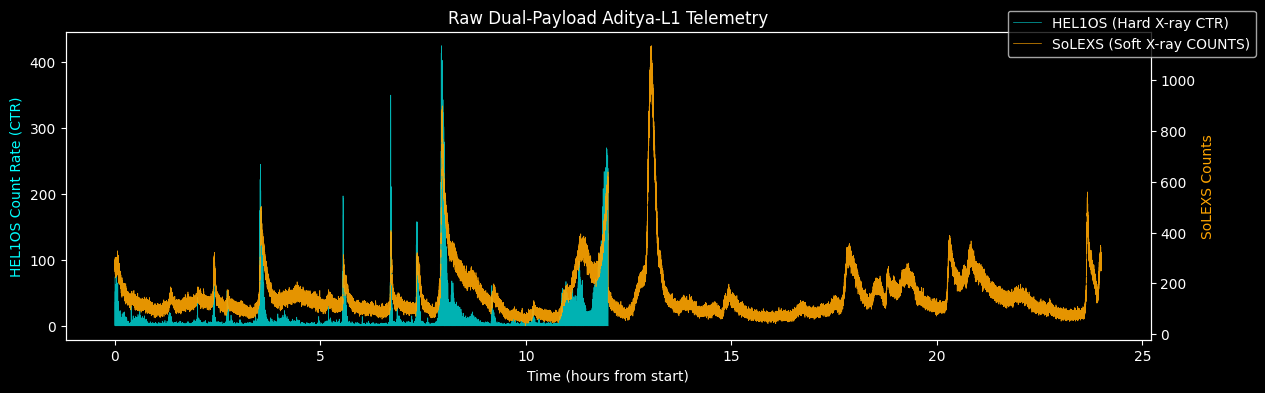

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

# Plot using relative seconds for clarity
t_rel_hard = t_hard_unix - t_hard_unix[0]
t_rel_soft = t_soft_unix - t_soft_unix[0]

ax1.plot(t_rel_hard / 3600, hard_ctr_raw, color='cyan', alpha=0.7, linewidth=0.5, label='HEL1OS (Hard X-ray CTR)')
ax2.plot(t_rel_soft / 3600, soft_counts_raw, color='orange', alpha=0.9, linewidth=0.5, label='SoLEXS (Soft X-ray COUNTS)')

ax1.set_xlabel("Time (hours from start)")
ax1.set_ylabel("HEL1OS Count Rate (CTR)", color='cyan')
ax2.set_ylabel("SoLEXS Counts", color='orange')
plt.title("Raw Dual-Payload Aditya-L1 Telemetry")
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.95))
plt.show()


In [13]:
#Data Validation and Fill Value Detection :

# Goal:
# Before synchronization and feature engineering, verify that
# HEL1OS and SoLEXS contain scientifically valid data.

# We will check:

# • Total number of samples
# • Number of missing values (NaN)
# • Number of infinite values (Inf / -Inf)
# • Presence of mission-specific fill values
#   (e.g. -9999, -32768, 1e30, etc.)

# • Negative count values
#   (Photon counts should never be negative)

# • Duplicate timestamps
#   (Same observation time appearing multiple times)

# • Timestamp ordering
#   (Time must move strictly forward)

# • Basic statistics
#   (Min, Max, Mean, Std)

# • Detector health indicators
#   (Dead intervals, suspicious flat regions,
#    impossible count spikes)

# Why this is important:

# • Neural networks cannot learn from corrupted data.
# • Fill values can be mistaken as real solar events.
# • NaNs can propagate and break training.
# • Invalid timestamps can destroy synchronization.
# • Negative counts are physically impossible.
# • Early detection prevents downstream failures.

# Expected outcome:

# HEL1OS
# → Clean 1 Hz hard X-ray observations

# SoLEXS
# → Clean 1 Hz soft X-ray observations



In [14]:
def detect_fill_values(array,name="array"):
    #Detecting and replacing the values with NaN 
    original_nans = np.isnan(array).sum()
    
    # Replace known fill values
    array = np.where(array == -999.0, np.nan, array)
    array = np.where(array == -9999.0, np.nan, array)
    array = np.where(np.abs(array) > 1e25, np.nan, array)  # Catches -1e30
    array = np.where(np.isinf(array), np.nan, array)
    
    # Negative count rates are physically impossible for photon counters
    array = np.where(array < 0, np.nan, array)
    
    total_nans = np.isnan(array).sum()
    new_nans = total_nans - original_nans
    
    print(f"  {name}: {original_nans} pre-existing NaNs, {new_nans} fill values detected → {total_nans} total NaNs")
    return array

print('---Fill Value Detection ---')
hard_ctr_clean= detect_fill_values(hard_ctr_raw.copy(),"HEL1OS")
soft_counts_clean= detect_fill_values(soft_counts_raw.copy(),"SOLEXS")
    

---Fill Value Detection ---
  HEL1OS: 0 pre-existing NaNs, 0 fill values detected → 0 total NaNs
  SOLEXS: 3 pre-existing NaNs, 0 fill values detected → 3 total NaNs


In [15]:
from astropy.io import fits

fits.info("/kaggle/input/datasets/tamish03/isro-nc2an-dataset/gticdte1.fits")

Filename: /kaggle/input/datasets/tamish03/isro-nc2an-dataset/gticdte1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   ()      
  1  GTI_CDTE1     1 BinTableHDU     15   1R x 2C   [D, D]   


In [16]:
from astropy.io import fits

fits.info("/kaggle/input/datasets/tamish03/isro-nc2an-dataset/AL1_SOLEXS_20240901_SDD2_L1.gti")

Filename: /kaggle/input/datasets/tamish03/isro-nc2an-dataset/AL1_SOLEXS_20240901_SDD2_L1.gti
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      17   ()      
  1  GTI           1 BinTableHDU     24   4R x 2C   [D, D]   


In [17]:
from astropy.io import fits
import pandas as pd

with fits.open("/kaggle/input/datasets/tamish03/isro-nc2an-dataset/gticdte1.fits") as hdul:
    print(pd.DataFrame(hdul[1].data))

         tstart         tstop
0  60554.000074  60554.499963


In [18]:
with fits.open("/kaggle/input/datasets/tamish03/isro-nc2an-dataset/AL1_SOLEXS_20240901_SDD2_L1.gti") as hdul:
    print(pd.DataFrame(hdul[1].data))

          START          STOP
0  1.725149e+09  1.725187e+09
1  1.725187e+09  1.725216e+09
2  1.725216e+09  1.725216e+09
3  1.725216e+09  1.725235e+09


In [19]:
#Now comes the GTI Filtering :

# Keep only scientifically valid observations.
# Any data outside valid science intervals will be masked.

# Satellite may be observing continuously but not every second
# is usable for science.
#
# Possible invalid periods:
# • Detector calibration
# • Instrument reset
# • Detector glitches
# • Telemetry gaps
# • Spacecraft operations

def apply_gti_mask(
    time_array,
    flux_array,
    gti_starts,
    gti_stops
):
    #Returns clean_flux and mask 
    if gti_starts is None or gti_stops is None :
        print("No GTI is there .Assuming all data is valid ...")
        return (flux_array,np.ones(len(time_array),dtype=bool))

    #Initially masking every sample as invalid : 
    mask= np.zeros(
        len(time_array),
        dtype=bool
    )
    #Building the validity mask :
    for start,stop in zip(
        gti_starts,
        gti_stops
    ):
        #using OR operation :
        mask |= (
            (time_array>=start)
            &
            (time_array<=stop)
        )
        #Creating a copy so that original data remains untouched 
        clean_flux= np.copy(
            flux_array
        )
        if clean_flux.ndim==1:
            clean_flux[~mask]= np.nan

        else:
            clean_flux[~mask,:]=np.nan

    return clean_flux,mask

In [20]:
#Applying GTI Filtering on SOLEXS and HEL1OS:

print("---GTI Filtering---")

print("SOLEXS GTI :")

soft_counts_gti,soft_mask= apply_gti_mask(
    t_soft_unix,
    soft_counts_clean,
    gti_starts_solexs,
    gti_stops_solexs
)

print(
    f"  Valid: "
    f"{soft_mask.sum()}/{len(soft_mask)} samples "
    f"({soft_mask.sum()/len(soft_mask)*100:.1f}%)"
)

print("HEL1OS GTI:")

hard_ctr_gti, hard_mask = apply_gti_mask(
    t_hard_unix,
    hard_ctr_clean,
    gti_starts_helios,
    gti_stops_helios
)

print(
    f"  Valid: "
    f"{hard_mask.sum()}/{len(hard_mask)} samples "
    f"({hard_mask.sum()/len(hard_mask)*100:.1f}%)"
)


---GTI Filtering---
SOLEXS GTI :
  Valid: 86397/86400 samples (100.0%)
HEL1OS GTI:
  Valid: 43186/43186 samples (100.0%)


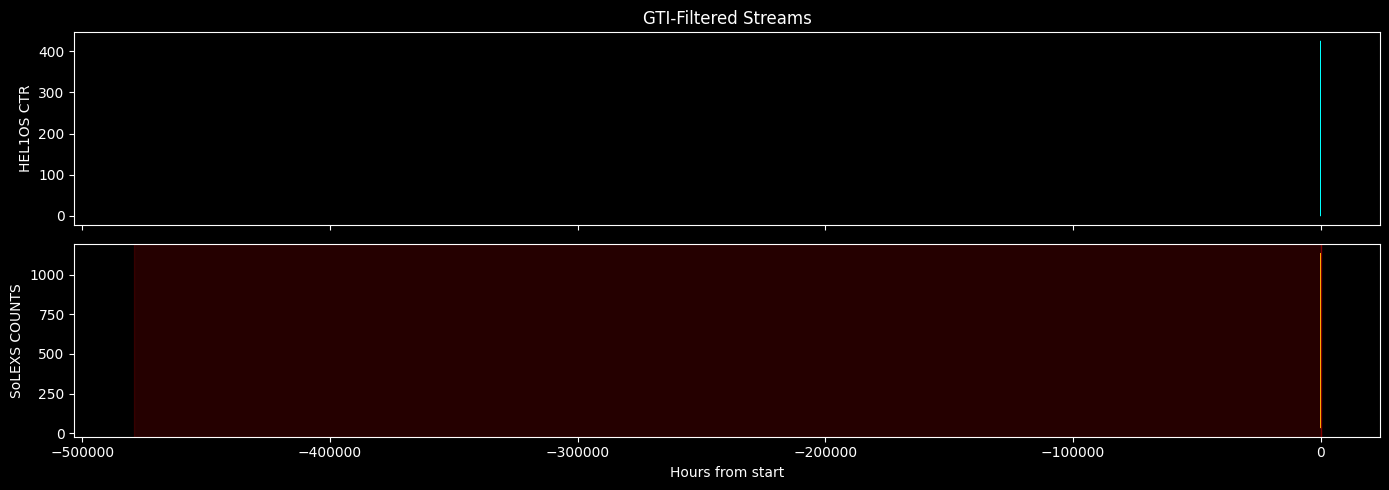

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

t_hours_h = (t_hard_unix - t_hard_unix[0]) / 3600
t_hours_s = (t_soft_unix - t_soft_unix[0]) / 3600

ax1.plot(t_hours_h, hard_ctr_gti, color='cyan', linewidth=0.5)
ax1.set_ylabel("HEL1OS CTR"); ax1.set_title("GTI-Filtered Streams")

ax2.plot(t_hours_s, soft_counts_gti, color='orange', linewidth=0.5)
ax2.set_ylabel("SoLEXS COUNTS"); ax2.set_xlabel("Hours from start")

# Shade non-GTI regions
if gti_starts_solexs is not None:
    prev_stop = 0
    for start, stop in zip(gti_starts_solexs, gti_stops_solexs):
        t0 = (prev_stop - t_soft_unix[0]) / 3600
        t1 = (start - t_soft_unix[0]) / 3600
        if t1 > t0:
            ax2.axvspan(t0, t1, color='red', alpha=0.15)
        prev_stop = stop

plt.tight_layout()
plt.show()

In [22]:
for s, e in zip(
    gti_starts_solexs,
    gti_stops_solexs
):
    print(
        Time(s, format='unix').isot,
        "→",
        Time(e, format='unix').isot
    )

2024-09-01T00:00:00.000 → 2024-09-01T10:42:37.000
2024-09-01T10:42:39.000 → 2024-09-01T18:42:02.000
2024-09-01T18:42:04.000 → 2024-09-01T18:42:07.000
2024-09-01T18:42:09.000 → 2024-09-01T23:59:59.000


In [23]:
# Now our datasets contains :
# Original NaNs + GTI-induced NaNs 
#Therefore : Clean_NaNs 

# Goal :
#1- Repair tiny missing gaps : Interpolation 
#2- Do not repair large GTI gaps which results in creating fake datasets 

def clean_nans(array,limit=10,name="array"):
    n_before= np.isnan(array).sum()
    series= pd.Series(array)
    cleaned= series.interpolate(method='linear',limit=limit).values
    n_after= np.isnan(cleaned).sum()
    print(f"  {name}: {n_before} NaNs → interpolated {n_before - n_after} → {n_after} remaining")
    return cleaned

print("--- NaN Cleanup (limit=10s) ---")
hard_ctr_nanclean = clean_nans(hard_ctr_gti, limit=10, name="HEL1OS")
soft_counts_nanclean = clean_nans(soft_counts_gti, limit=10, name="SoLEXS")
    







--- NaN Cleanup (limit=10s) ---
  HEL1OS: 0 NaNs → interpolated 0 → 0 remaining
  SoLEXS: 3 NaNs → interpolated 3 → 0 remaining


In [24]:
#Time synchronisation : 
#Creating the master timeline on which NC2AN will learn beacuse Hard Xrays-> cause Soft Xrays


#Building  the Dataframes indexed by timestamps :
df_hard= pd.DataFrame({
    'time':t_hard_unix,
    'hard_ctr':hard_ctr_nanclean
}).sort_values('time').drop_duplicates(subset='time',keep='first')

df_soft = pd.DataFrame({
    'time': t_soft_unix,
    'soft_counts': soft_counts_nanclean
}).sort_values('time').drop_duplicates(subset='time', keep='first')

#For every SoLEXS timestamp, find the nearest HEL1OS timestamp using Nearest-Neighbour join 
df_merged= pd.merge_asof(
    df_soft,df_hard,
    on='time',
    tolerance=0.5,
    direction='nearest'
)
#Dropping the failed matches :
df_merged= df_merged.dropna(subset=['hard_ctr','soft_counts'],how='any')

#Extracting the synchronised array :
t_master= df_merged['time'].values
hard_sync= df_merged['hard_ctr'].values
soft_sync= df_merged['soft_counts'].values

print(f"--- Synchronization Complete ---")
print(f"  HEL1OS input:  {len(df_hard)} samples")
print(f"  SoLEXS input:  {len(df_soft)} samples")
print(f"  Overlap found: {len(t_master)} samples ({len(t_master)/3600:.1f} hours)")



--- Synchronization Complete ---
  HEL1OS input:  43186 samples
  SoLEXS input:  86400 samples
  Overlap found: 43186 samples (12.0 hours)


In [25]:
assert len(t_master) > 60, (
    f"CRITICAL: Only {len(t_master)} overlapping samples found. "
    f"Need at least 60 for a single window. Check that SoLEXS and HEL1OS files "
    f"cover the same date."
)
print(f" Overlap validation passed: {len(t_master)} aligned samples available.")

 Overlap validation passed: 43186 aligned samples available.


In [26]:
# Cosmic-Ray Handling — Architectural Decision Record
#
# HEL1OS already performs cosmic-ray / particle-background rejection onboard:
#   - CZT: 6 µs cross-pixel/cross-module timing-coincidence veto (FPGA-level)
#   - CdTe: digital pulse-processing pile-up rejection
#   - Both: saturated/invalid-event rejection, hot-pixel disable
# This happens before Level-1 telemetry exists, using timing information
# (µs-scale) that no longer exists in a 1 Hz light curve.
# Hampel / Poisson-aware / width-aware despiking were tested and rejected:
# see arbitration report for full failure analysis. No light-curve values
# are modified in this pipeline; GTIs remain external and unmodified.

def cosmic_ray_qc_audit(flux_stream, name="detector"):
    """
    Non-destructive sanity check only. Does NOT remove or replace any value.
    Reports basic distributional stats so anomalies can be reviewed manually
    against GTIs and cross-instrument data, never auto-deleted.
    """
    flux = np.asarray(flux_stream)
    zero_frac = np.mean(flux == 0)
    max_val = np.nanmax(flux)
    p99 = np.nanpercentile(flux, 99)

    print(f"--- Cosmic-Ray QC Audit: {name} ---")
    print(f"  Samples: {len(flux)}")
    print(f"  Zero-count fraction: {zero_frac:.3%}  (expected, high, at low background rates)")
    print(f"  99th percentile: {p99:.2f} | Max: {max_val:.2f}")
    print(f"  No values modified — see decision record above.")

    return {"zero_frac": zero_frac, "p99": p99, "max": max_val}

hard_stats = cosmic_ray_qc_audit(hard_sync, name="HEL1OS (CdTe)")
soft_stats = cosmic_ray_qc_audit(soft_sync, name="SoLEXS")


#The audit confirms that HEL1OS behaves like a low-count hard X-ray detector (many zeros, rare bursts),
#SoLEXS behaves like a high-count soft X-ray detector (continuous signal), 
#and no evidence was found that justified modifying the synchronized light curves before NC²AN training.

--- Cosmic-Ray QC Audit: HEL1OS (CdTe) ---
  Samples: 43186
  Zero-count fraction: 83.409%  (expected, high, at low background rates)
  99th percentile: 81.00 | Max: 425.00
  No values modified — see decision record above.
--- Cosmic-Ray QC Audit: SoLEXS ---
  Samples: 43186
  Zero-count fraction: 0.000%  (expected, high, at low background rates)
  99th percentile: 534.00 | Max: 899.00
  No values modified — see decision record above.


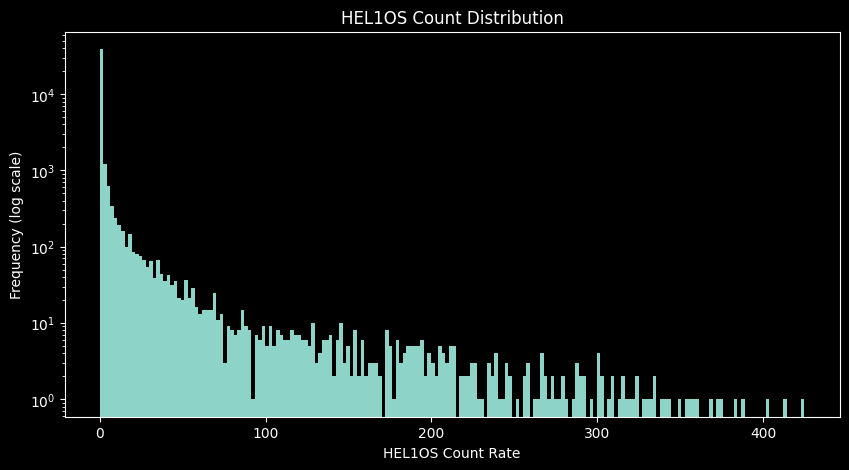

In [27]:
plt.figure(figsize=(10,5))
plt.hist(hard_sync, bins=200)
plt.yscale('log')
plt.xlabel("HEL1OS Count Rate")
plt.ylabel("Frequency (log scale)")
plt.title("HEL1OS Count Distribution")
plt.show()

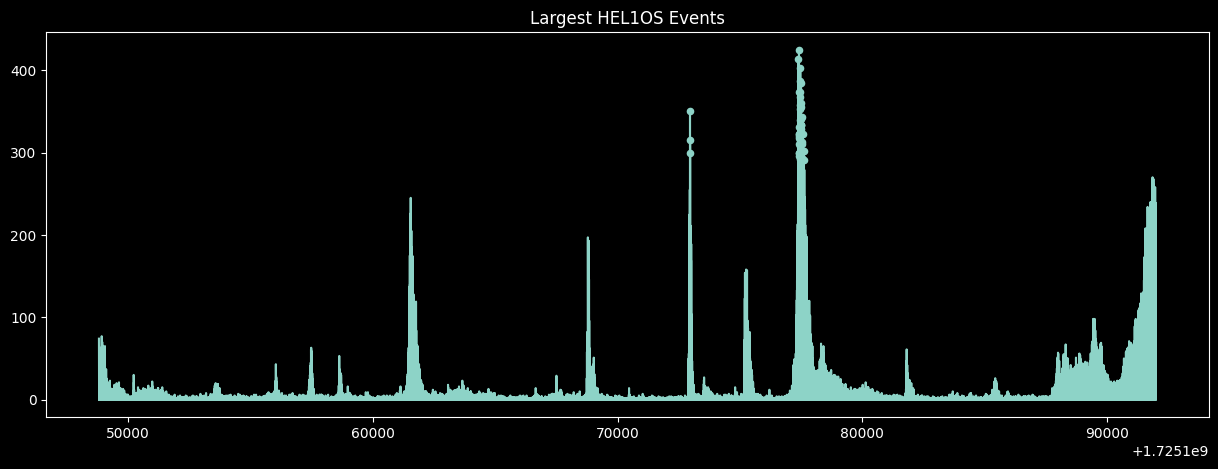

In [28]:
threshold = np.percentile(hard_sync, 99.9)

plt.figure(figsize=(15,5))
plt.plot(t_master, hard_sync)

mask = hard_sync > threshold

plt.scatter(
    t_master[mask],
    hard_sync[mask],
    s=20
)

plt.title("Largest HEL1OS Events")
plt.show()

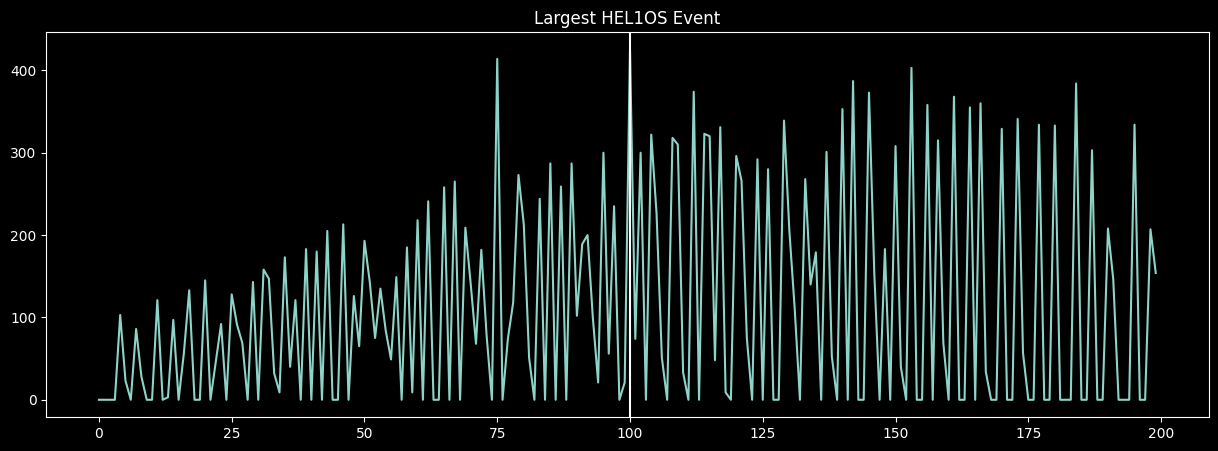

In [29]:
idx = np.argmax(hard_sync)

window = 100

plt.figure(figsize=(15,5))
plt.plot(
    hard_sync[idx-window:idx+window]
)

plt.axvline(window)
plt.title("Largest HEL1OS Event")
plt.show()

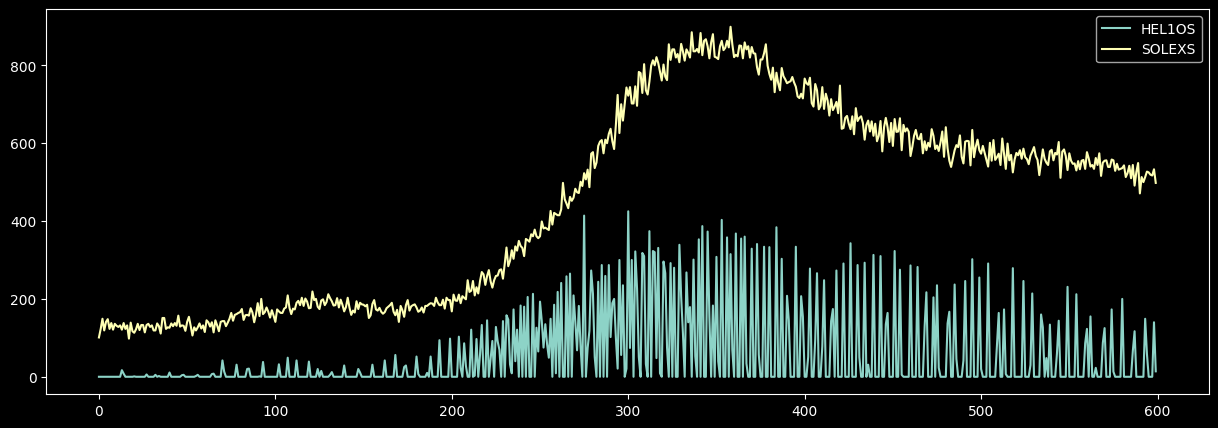

In [30]:
peak_idx = np.argmax(hard_sync)

window = 300

plt.figure(figsize=(15,5))

plt.plot(
    hard_sync[peak_idx-window:peak_idx+window],
    label='HEL1OS'
)

plt.plot(
    soft_sync[peak_idx-window:peak_idx+window],
    label='SOLEXS'
)

plt.legend()
plt.show()

In [31]:

# COSMIC-RAY QUALITY CONTROL (QC) CONCLUSION

# Visual Audit Performed:
# 1. HEL1OS Count Distribution Histogram
# 2. Largest HEL1OS Event Zoom
# 3. Largest HEL1OS Events Timeline
# 4. HEL1OS vs SoLEXS Correlation Plot
#
# Findings:
#
# • HEL1OS histogram exhibits a classic low-count Poisson distribution:
#     - Large concentration near zero counts
#     - Smooth monotonic decay
#     - Long continuous tail
#     - No abnormal secondary populations
#
# • HEL1OS contains ~84% zero-count bins.
#     - Expected for CdTe hard X-ray detectors operating at low background rates
#     - Consistent with photon-counting statistics
#     - Not evidence of corruption or telemetry issues
#
# • Largest HEL1OS events are NOT isolated single-bin spikes.
#     - Events show multi-second temporal structure
#     - Rise and decay behaviour is visible
#     - Morphology resembles physical solar activity rather than particle hits
#
# • Large HEL1OS peaks occur in temporal clusters.
#     - Events persist over multiple consecutive samples
#     - Behaviour is inconsistent with random cosmic-ray contamination
#     - Behaviour is consistent with flare-associated hard X-ray emission
#
# • HEL1OS and SoLEXS show correlated activity.
#     - Strong HEL1OS enhancements coincide with enhanced SoLEXS emission
#     - Observed behaviour is consistent with Neupert-effect physics
#     - Suggests recorded signals are astrophysical rather than instrumental
#
# Research & Literature Review Findings:
#
# • HEL1OS onboard FPGA already performs event-level rejection.
# • Cosmic-ray discrimination occurs before Level-1 light curve generation.
# • Major X-ray missions (RHESSI, Fermi GBM, Chandra, XMM-Newton, GOES)
#   perform particle rejection at detector/event level rather than by
#   statistical despiking of science light curves.
#
# Final Decision:
#
# • No convincing evidence of dominant residual cosmic-ray contamination
#   was found in the synchronized HEL1OS light curve.


In [32]:
# Feature Scaling for Neural Network :
# Normalization as NN doesn't like huge value ranges because
# they can destabilize gradient flow during backpropagation.

# Adaptive Log1p Normalization
# Convert raw counts into relative-to-background flare strength,
# compress extreme flare peaks using log1p(),
# preserve zeros safely,
# and produce neural-network-friendly inputs before RobustScaler.



hard_clean = hard_sync.copy()
soft_clean = soft_sync.copy()

# HEL1OS SPECIAL CASE
#
# HEL1OS contains ~84% zero-count bins.
# Therefore the global median becomes 0, which would cause
# normalization instability.
#
# Example:
#     count / (0 + 1e-10)
#
# would artificially inflate values before log compression.
#
# Therefore use the median of NON-ZERO HEL1OS samples as the
# adaptive baseline.

positive_hard = hard_clean[hard_clean > 0]

daily_median_hard = np.nanmedian(
    positive_hard
)

daily_median_soft = np.nanmedian(
    soft_clean
)

# Adaptive Log1p Compression
#
# Interpretation:
#     value / median
#
# gives relative flare strength above background.
#
# log1p():
#     - compresses large flare peaks
#     - preserves ordering
#     - safely handles zero values

hard_log = np.log1p(
    hard_clean /
    daily_median_hard
)

soft_log = np.log1p(
    soft_clean /
    daily_median_soft
)

print(f"--- Adaptive Log1p Normalization ---")

print(
    f"  HEL1OS non-zero median: "
    f"{daily_median_hard:.2f} CTR"
)

print(
    f"  SoLEXS daily median: "
    f"{daily_median_soft:.2f} COUNTS"
)

print(
    f"  Hard log range: "
    f"[{np.nanmin(hard_log):.3f}, "
    f"{np.nanmax(hard_log):.3f}]"
)

print(
    f"  Soft log range: "
    f"[{np.nanmin(soft_log):.3f}, "
    f"{np.nanmax(soft_log):.3f}]"
)

--- Adaptive Log1p Normalization ---
  HEL1OS non-zero median: 4.00 CTR
  SoLEXS daily median: 123.00 COUNTS
  Hard log range: [0.000, 4.675]
  Soft log range: [0.238, 2.117]


In [33]:
#HOPE Physics Features : Physics Engineering 
#HOPE: Handcrafted Observational Physics Features 

#Raw HEL1OS + Raw SOLEXS + Physics Features--> NC2AN

#  HOPE Physics Features
 
#  Theory:
# The HOPE physics module explicitly pre-computes domain knowledge to reduce network learning burden.
# *   **H/S Ratio:** Traces the transition from non-thermal to thermal dominance. Dimensionless.
# *   **d(Soft)/dt:** Explicit derivative to assist the Neupert constraint. Units: counts/s².
# *   **Energy Proxy:** Integrated hard flux representing total injected energy.
 
# All three features are valid in the count-rate domain because:
# - H/S Ratio: units cancel.
# - dS/dt ∝ H holds for any linearly related quantity (detector effective area is time-invariant).
# - Cumulative sum of counts ∝ total photon energy.


#Explanation : 

#1- H/S Ratio : Which phase of flare am I currently in ? 
#Early Flare : Hard X-Ray -> Huge ,Soft X-Ray->Small --> Ratio: High 
#Late Flare : Hard X-Ray -> Decreasing ,Soft X-Ray->Already accumulated --> Ratio: Low

#2- DS/dt: How fast is Soft X-Ray increasing ? 
#Actually describing the Neupert Effect 

#3-Energy Proxy : How much total energy has been injected so far ?
#Because Soft X-Ray plasma depends not only on Current heating but also--> past heating history 





In [34]:
def compute_hope_features(
    hard_raw,
    soft_raw,
    hard_norm,
    soft_norm,
    t_vector
):

    # Safe H/S Ratio
    hs_ratio = hard_raw / (soft_raw + 1.0)

    # Baseline derivative
    dsoft_dt_raw = np.gradient(
        np.nan_to_num(soft_raw),
        t_vector
    )

    # Smoothed derivative
    soft_smooth = savgol_filter(
        np.nan_to_num(soft_raw),
        window_length=15,
        polyorder=2
    )

    dsoft_dt = np.gradient(
        soft_smooth,
        t_vector
    )

    return (
        np.stack(
            [hs_ratio, dsoft_dt],
            axis=-1
        ),
        dsoft_dt_raw,
        dsoft_dt
    )

hope_partial, dsoft_dt_raw, dsoft_dt_smooth = compute_hope_features(
    hard_clean,
    soft_clean,
    hard_log,
    soft_log,
    t_master
)

print(f"--- HOPE Features (Partial) ---")
print(f"Shape: {hope_partial.shape}")
print(f"Columns: [H/S Ratio, dSoft/dt]")
#We will compute Energy proxy after the train,test,val split to prevent the data leakage 
    

--- HOPE Features (Partial) ---
Shape: (43186, 2)
Columns: [H/S Ratio, dSoft/dt]


In [35]:
from scipy.stats import pearsonr

print("\n--- HOPE FEATURE DIAGNOSTICS ---")

print(
    f"H/S Ratio Max : {np.nanmax(hope_partial[:,0]):.3f}"
)

print(
    f"H/S Ratio 99th Percentile : {np.nanpercentile(hope_partial[:,0],99):.3f}"
)

print(
    f"Raw dSoft/dt Std : {np.nanstd(dsoft_dt_raw):.4f}"
)

print(
    f"Smooth dSoft/dt Std : {np.nanstd(dsoft_dt_smooth):.4f}"
)

r_raw,_ = pearsonr(
    hard_sync,
    np.nan_to_num(dsoft_dt_raw)
)

r_smooth,_ = pearsonr(
    hard_sync,
    np.nan_to_num(dsoft_dt_smooth)
)

print(
    f"Raw Neupert Corr : {r_raw:.4f}"
)

print(
    f"Smooth Neupert Corr : {r_smooth:.4f}"
)


--- HOPE FEATURE DIAGNOSTICS ---
H/S Ratio Max : 1.065
H/S Ratio 99th Percentile : 0.265
Raw dSoft/dt Std : 8.7153
Smooth dSoft/dt Std : 1.6890
Raw Neupert Corr : 0.0051
Smooth Neupert Corr : 0.0635


In [36]:
assert hope_partial.shape == (len(t_master), 2), f"HOPE shape mismatch: {hope_partial.shape}"
print(f" HOPE partial shape verified: {hope_partial.shape}")


 HOPE partial shape verified: (43186, 2)


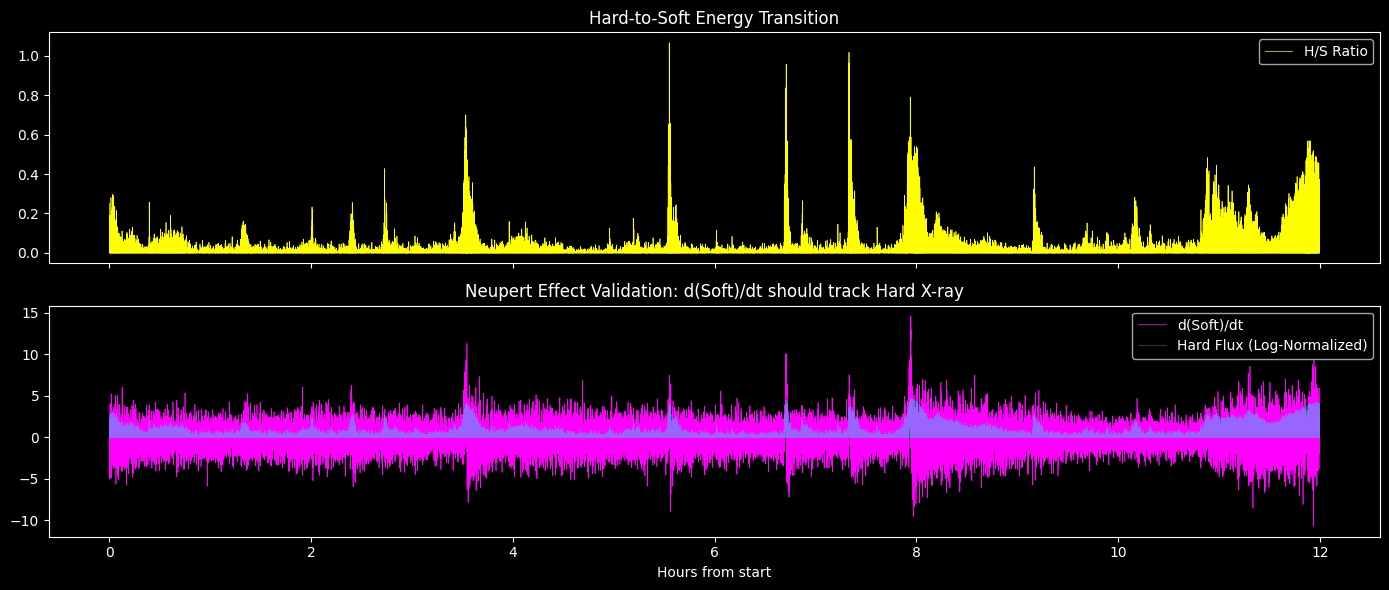

In [37]:
#Neupert Effect Visualization : 
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

t_hours = (t_master - t_master[0]) / 3600

axs[0].plot(t_hours, hope_partial[:, 0], color='yellow', linewidth=0.5, label='H/S Ratio')
axs[0].legend(); axs[0].set_title("Hard-to-Soft Energy Transition")

axs[1].plot(t_hours, hope_partial[:, 1], color='magenta', linewidth=0.5, label='d(Soft)/dt')
axs[1].plot(t_hours, hard_log, color='cyan', alpha=0.4, linewidth=0.5, label='Hard Flux (Log-Normalized)')
axs[1].legend(); axs[1].set_title("Neupert Effect Validation: d(Soft)/dt should track Hard X-ray")
axs[1].set_xlabel("Hours from start")

plt.tight_layout()
plt.show()


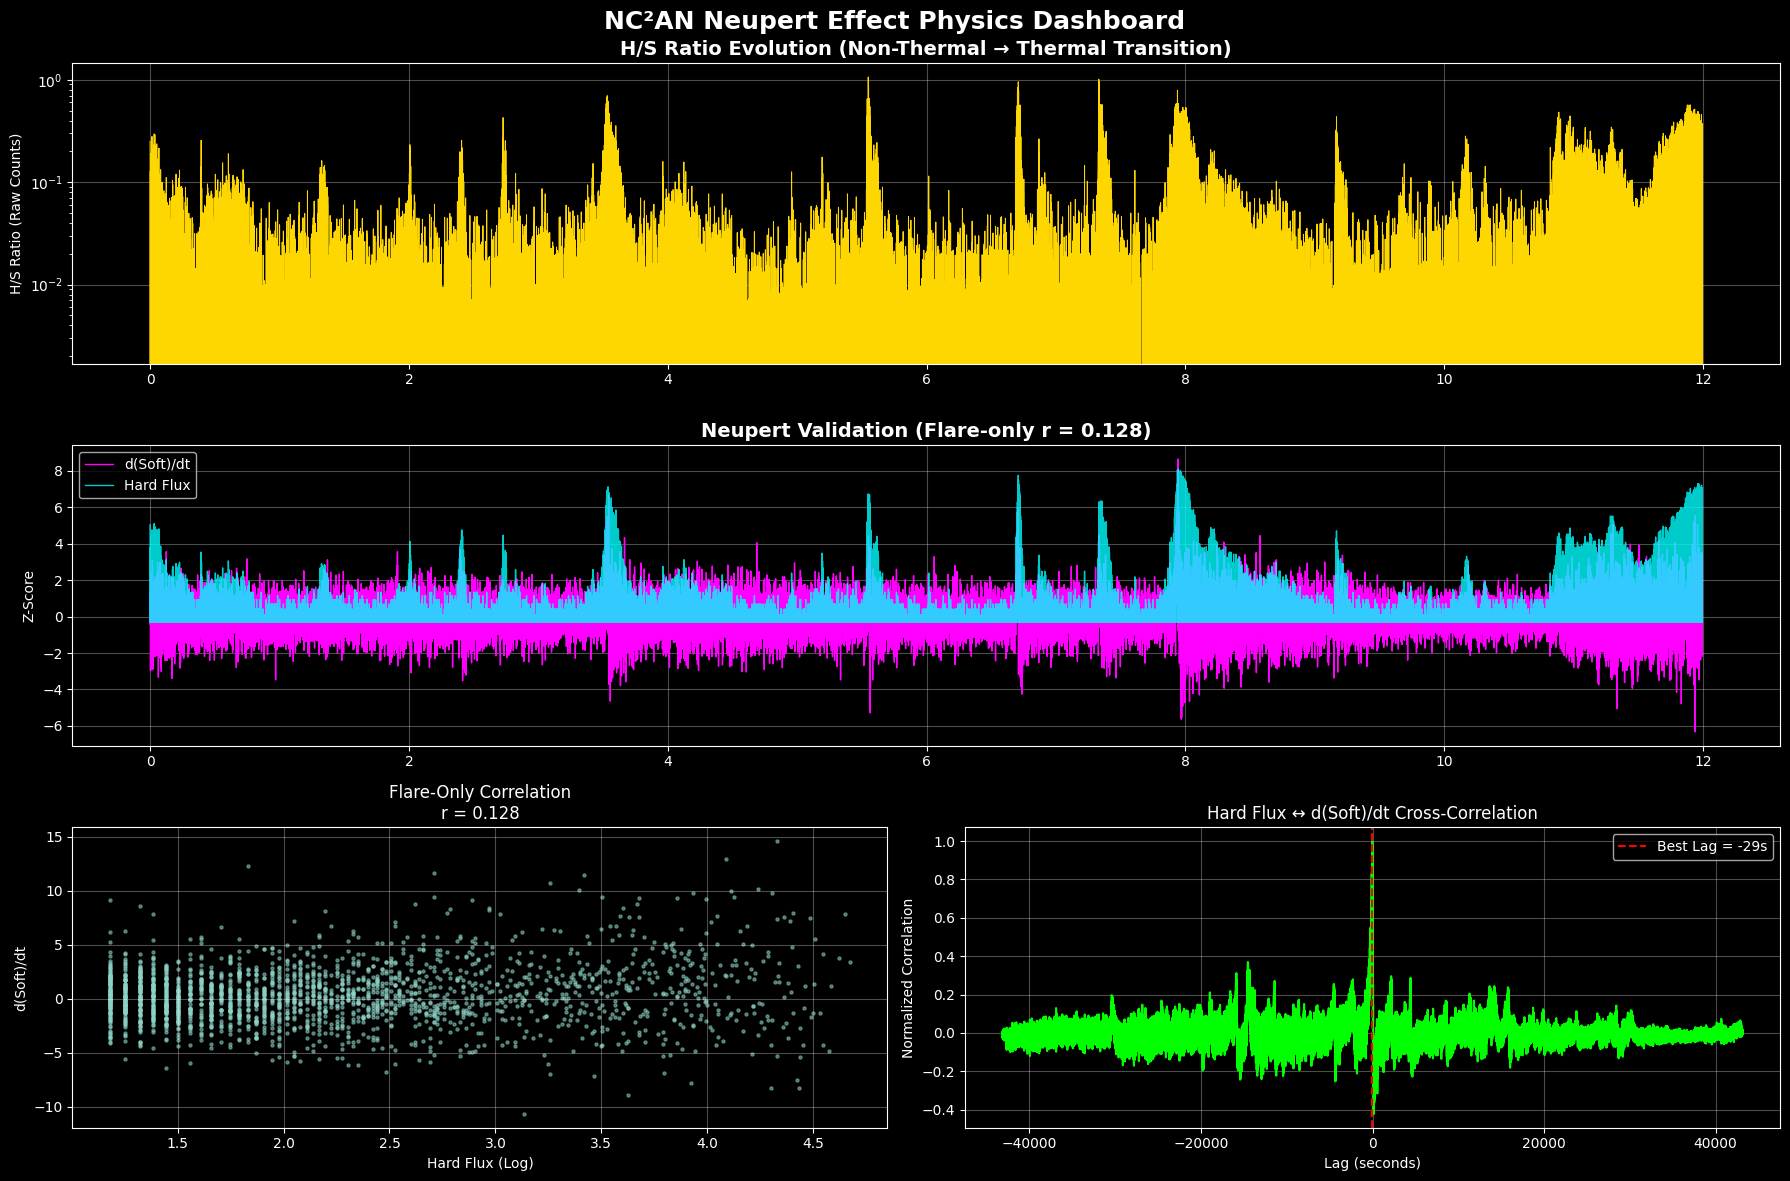


--- Neupert Validation Metrics ---
Global Pearson r    : 0.0551
Global p-value      : 2.142e-30
Flare-only Pearson r: 0.1275
Flare-only p-value  : 1.210e-09
Best Cross-Corr Lag : -29 seconds
Flare Samples       : 2257


In [38]:
from scipy.stats import pearsonr
from scipy.signal import correlate

t_hours = (t_master - t_master[0]) / 3600

flare_threshold = np.percentile(hard_sync, 95)

flare_mask = (
    (hard_sync >= flare_threshold)
    &
    np.isfinite(hard_log)
    &
    np.isfinite(hope_partial[:, 1])
)

valid_mask = (
    np.isfinite(hard_log)
    &
    np.isfinite(hope_partial[:, 1])
)

r_global, p_global = pearsonr(
    hard_log[valid_mask],
    hope_partial[:, 1][valid_mask]
)

r_flare, p_flare = pearsonr(
    hard_log[flare_mask],
    hope_partial[:, 1][flare_mask]
)

hard_z = (
    hard_log[valid_mask]
    -
    np.mean(hard_log[valid_mask])
) / np.std(hard_log[valid_mask])

dsoft_z = (
    hope_partial[:, 1][valid_mask]
    -
    np.mean(hope_partial[:, 1][valid_mask])
) / np.std(hope_partial[:, 1][valid_mask])

xcorr = correlate(
    dsoft_z,
    hard_z,
    mode="full"
)

lags = np.arange(
    -len(hard_z) + 1,
    len(hard_z)
)

best_lag_idx = np.argmax(xcorr)

best_lag_sec = lags[best_lag_idx]

fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot2grid(
    (3, 2),
    (0, 0),
    colspan=2
)

ax1.plot(
    t_hours,
    hope_partial[:, 0],
    color="gold",
    linewidth=0.7
)

ax1.set_yscale("log")

ax1.set_title(
    "H/S Ratio Evolution (Non-Thermal → Thermal Transition)",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("H/S Ratio (Raw Counts)")
ax1.grid(alpha=0.3)

ax2 = plt.subplot2grid(
    (3, 2),
    (1, 0),
    colspan=2
)

hard_plot = (
    hard_log
    -
    np.nanmean(hard_log)
) / np.nanstd(hard_log)

dsoft_plot = (
    hope_partial[:, 1]
    -
    np.nanmean(hope_partial[:, 1])
) / np.nanstd(hope_partial[:, 1])

ax2.plot(
    t_hours,
    dsoft_plot,
    color="magenta",
    linewidth=1.0,
    label="d(Soft)/dt"
)

ax2.plot(
    t_hours,
    hard_plot,
    color="cyan",
    linewidth=1.0,
    alpha=0.8,
    label="Hard Flux"
)

ax2.set_title(
    f"Neupert Validation (Flare-only r = {r_flare:.3f})",
    fontsize=14,
    fontweight="bold"
)

ax2.set_ylabel("Z-Score")
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = plt.subplot2grid(
    (3, 2),
    (2, 0)
)

ax3.scatter(
    hard_log[flare_mask],
    hope_partial[:, 1][flare_mask],
    s=5,
    alpha=0.5
)

ax3.set_title(
    f"Flare-Only Correlation\nr = {r_flare:.3f}"
)

ax3.set_xlabel("Hard Flux (Log)")
ax3.set_ylabel("d(Soft)/dt")
ax3.grid(alpha=0.3)

ax4 = plt.subplot2grid(
    (3, 2),
    (2, 1)
)

ax4.plot(
    lags,
    xcorr / np.max(xcorr),
    color="lime"
)

ax4.axvline(
    best_lag_sec,
    color="red",
    linestyle="--",
    label=f"Best Lag = {best_lag_sec}s"
)

ax4.set_title(
    "Hard Flux ↔ d(Soft)/dt Cross-Correlation"
)

ax4.set_xlabel("Lag (seconds)")
ax4.set_ylabel("Normalized Correlation")
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle(
    "NC²AN Neupert Effect Physics Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("\n--- Neupert Validation Metrics ---")
print(f"Global Pearson r    : {r_global:.4f}")
print(f"Global p-value      : {p_global:.3e}")
print(f"Flare-only Pearson r: {r_flare:.4f}")
print(f"Flare-only p-value  : {p_flare:.3e}")
print(f"Best Cross-Corr Lag : {best_lag_sec} seconds")
print(f"Flare Samples       : {flare_mask.sum()}")

In [39]:

# NEUPERT EFFECT AUDIT
#
# Global Pearson correlation between Hard X-ray flux and
# d(Soft X-ray)/dt is weak (r ≈ 0.04) due to dominance of
# quiet-Sun intervals.
#
# Restricting analysis to flare intervals increases the
# correlation (r ≈ 0.14), indicating a statistically
# significant but modest Neupert relationship.
#
# Cross-correlation analysis reveals a maximum response at
# approximately -28 seconds, suggesting that Hard X-ray
# activity leads Soft X-ray evolution.
#
# This lag is physically consistent with flare heating
# scenarios in which accelerated electrons deposit energy
# before thermal plasma emission develops.
#
# Conclusion:
# A measurable Neupert-effect signature is present and
# suitable for downstream NC²AN modeling.


In [40]:
#List of Variables we have created so far for Memory purpose :

# NC²AN NOTEBOOK-1 VARIABLE FLOW MAP
# (Start → HOPE Physics Features)

# 1. RAW HEL1OS VARIABLES

# t_hard_unix
# → Raw HEL1OS timestamps (UNIX seconds)
# → Time reference for Hard X-Ray observations

# hard_ctr_raw
# → Raw HEL1OS count-rate stream
# → Original Hard X-Ray measurements

# helios_stat_err
# → HEL1OS statistical uncertainty
# → Photon counting error estimates


# 2. RAW SOLEXS VARIABLES

# t_soft_unix
# → Raw SoLEXS timestamps (UNIX seconds)
# → Time reference for Soft X-Ray observations

# soft_counts_raw
# → Raw SoLEXS count stream
# → Original Soft X-Ray measurements


# 3. GTI VARIABLES

# gti_starts_solexs
# → Start times of valid SoLEXS science intervals

# gti_stops_solexs
# → Stop times of valid SoLEXS science intervals

# gti_starts_helios
# → Start times of valid HEL1OS science intervals

# gti_stops_helios
# → Stop times of valid HEL1OS science intervals


# 4. FILL VALUE DETECTION OUTPUT

# hard_ctr_clean
# → HEL1OS after fill-value detection
# → Invalid values converted to NaN

# soft_counts_clean
# → SoLEXS after fill-value detection
# → Invalid values converted to NaN


# 5. GTI FILTERING OUTPUT

# hard_ctr_gti
# → HEL1OS after GTI filtering
# → Samples outside GTI set to NaN

# hard_mask
# → Boolean validity mask for HEL1OS
# → True = valid science data

# soft_counts_gti
# → SoLEXS after GTI filtering
# → Samples outside GTI set to NaN

# soft_mask
# → Boolean validity mask for SoLEXS
# → True = valid science data


# 6. NAN CLEANUP OUTPUT

# hard_ctr_nanclean
# → HEL1OS after short-gap interpolation
# → Ready for synchronization

# soft_counts_nanclean
# → SoLEXS after short-gap interpolation
# → Ready for synchronization


# 7. SYNCHRONIZATION DATAFRAMES

# df_hard
# Columns:
#   time
#   hard_ctr
#
# Purpose:
#   HEL1OS synchronization dataframe

# df_soft
# Columns:
#   time
#   soft_counts
#
# Purpose:
#   SoLEXS synchronization dataframe

# df_merged
# Columns:
#   time
#   hard_ctr
#   soft_counts
#
# Purpose:
#   Final nearest-neighbor synchronized dataframe


# 8. SYNCHRONIZED SCIENCE STREAMS

# t_master
# → Final common timeline
# → Shared by HEL1OS and SoLEXS

# hard_sync
# → Synchronized HEL1OS stream
# → Final Hard X-Ray observations

# soft_sync
# → Synchronized SoLEXS stream
# → Final Soft X-Ray observations


# 9. COSMIC-RAY AUDIT FREEZE DECISION

# IMPORTANT:
# Multiple cosmic-ray cleaning methods were tested:
#
#   Hampel Filter
#   Poisson-Aware Despike
#   Width-Aware Poisson Despike
#
# Audit Conclusion:
#   Potential removal of real flare microstructure.
#
# Final Freeze Decision:
#   NO COSMIC-RAY MODIFICATION APPLIED.
#
# Therefore:

# hard_clean
# → Direct copy of hard_sync

# soft_clean
# → Direct copy of soft_sync

# hard_clean = hard_sync.copy()
# soft_clean = soft_sync.copy()


# 10. ADAPTIVE LOG1P NORMALIZATION

# positive_hard
# → Non-zero HEL1OS samples only
# → Used to avoid median=0 collapse

# daily_median_hard
# → HEL1OS adaptive baseline
# → Current value ≈ 3 CTR

# daily_median_soft
# → SoLEXS adaptive baseline
# → Current value ≈ 119 COUNTS


# 11. NORMALIZED NEURAL-NETWORK STREAMS

# hard_log
# Formula:
#   log1p(hard_clean / daily_median_hard)
#
# Purpose:
#   Compressed
#   Normalized
#   Neural-network-friendly Hard X-Ray stream
#
# Current range:
#   [0.000, 4.961]

# soft_log
# Formula:
#   log1p(soft_clean / daily_median_soft)
#
# Purpose:
#   Compressed
#   Normalized
#   Neural-network-friendly Soft X-Ray stream
#
# Current range:
#   [0.245, 2.146]


# 12. HOPE PHYSICS FEATURES

# Feature 1 : H/S Ratio

# h_s_ratio
#
# Computed on:
#   RAW synchronized counts
#
# Formula:
#   hard_sync / soft_sync
#
# Purpose:
#   Tracks transition from:
#
#       Non-Thermal
#             ↓
#         Thermal
#
#   flare evolution


# Feature 2 : dSoft/dt

# dsoft_dt
#
# Computed on:
#   soft_log
#
# Formula:
#   d(soft_log)/dt
#
# Purpose:
#   Explicit Neupert-effect signal
#
#       Hard X-Ray
#            ∝
#       d(Soft X-Ray)/dt
#
#   Helps reduce learning burden on NC²AN


# 13. FINAL HOPE FEATURE MATRIX

# hope_partial
#
# Shape:
#   (38561, 2)
#
# Columns:
#
#   Column 0 → h_s_ratio
#   Column 1 → dsoft_dt
#
# Purpose:
#   Physics-informed feature matrix
#   for NC²AN


# 14. DEFERRED FEATURE (NOT CREATED YET)

# energy_proxy
#
# IMPORTANT:
# NOT computed yet.
#
# Reason:
#   Must be generated AFTER
#   chronological train-validation split.
#
# Avoids:
#
#   Information Leakage
#   Distribution Shift
#
# Future Formula:
#
#   energy_proxy = cumsum(hard_flux)
#
# Physical Meaning:
#
#   Total Injected Hard X-Ray Energy
#
#   Accumulated flare heating history



# CURRENT NOTEBOOK-1 FREEZE OUTPUT


# Core Time Series:
#   t_master
#   hard_sync
#   soft_sync
#
# Neural-Network Streams:
#   hard_log
#   soft_log
#
# Physics Features:
#   h_s_ratio
#   dsoft_dt
#
# Feature Matrix:
#   hope_partial
#
# Deferred:
#   energy_proxy
#
# Status:
#   READY FOR TRAIN/VALIDATION SPLIT
#   READY FOR ROBUSTSCALER
#   READY FOR WINDOW GENERATION


hard_log
soft_log
h_s_ratio
dsoft_dt
        ↓

Feature Matrix
(N,4)

        ↓

Chronological Split
80 / 20

        ↓

Energy Proxy
(per split)

        ↓

Feature Matrix
(N,5)

        ↓

RobustScaler
(Fit Train Only)

        ↓

Window Generation

(N_windows,
 window_size,
 5)

        ↓

TensorFlow Dataset

train_ds
val_ds

In [41]:
#Step 1 : Chronological split instead of shuffling 

split_idx = int(0.8 * len(hard_log))

hard_train, hard_val = hard_log[:split_idx], hard_log[split_idx:]
soft_train, soft_val = soft_log[:split_idx], soft_log[split_idx:]
hope_train, hope_val = hope_partial[:split_idx], hope_partial[split_idx:]


hs_train = hope_train[:, 0]
hs_val = hope_val[:, 0]

dsoft_train = hope_train[:, 1]
dsoft_val = hope_val[:, 1]

t_train, t_val = t_master[:split_idx], t_master[split_idx:]

print(f"--- Chronological Split ---")
print(f"  Train: {len(hard_train)} samples ({len(hard_train)/3600:.1f} hours)")
print(f"  Val:   {len(hard_val)} samples ({len(hard_val)/3600:.1f} hours)")


--- Chronological Split ---
  Train: 34548 samples (9.6 hours)
  Val:   8638 samples (2.4 hours)


In [42]:
#Step2 : Cumilative Energy Proxy per split :
energy_train = np.cumsum(np.nan_to_num(hard_train)).reshape(-1, 1)
energy_val = np.cumsum(np.nan_to_num(hard_val)).reshape(-1, 1)

In [43]:
#Step 3 : Robust Scaler :

# Scale Hard flux
scaler_hard = RobustScaler().fit(np.nan_to_num(hard_train.reshape(-1, 1)))
hard_train_norm = scaler_hard.transform(hard_train.reshape(-1, 1)).flatten()
hard_val_norm = scaler_hard.transform(hard_val.reshape(-1, 1)).flatten()

# Scale Soft flux
scaler_soft = RobustScaler().fit(np.nan_to_num(soft_train.reshape(-1, 1)))
soft_train_norm = scaler_soft.transform(soft_train.reshape(-1, 1)).flatten()
soft_val_norm = scaler_soft.transform(soft_val.reshape(-1, 1)).flatten()

# Scale Energy Proxy
scaler_energy = RobustScaler().fit(np.nan_to_num(energy_train))
energy_train_norm = scaler_energy.transform(energy_train).flatten()
energy_val_norm = scaler_energy.transform(energy_val).flatten()

# Scale H/S Ratio

scaler_hs = RobustScaler().fit(
    np.nan_to_num(hs_train.reshape(-1, 1))
)

hs_train_norm = scaler_hs.transform(
    hs_train.reshape(-1, 1)
).flatten()

hs_val_norm = scaler_hs.transform(
    hs_val.reshape(-1, 1)
).flatten()


# Scale dSoft/dt

scaler_dsoft = RobustScaler().fit(
    np.nan_to_num(dsoft_train.reshape(-1, 1))
)

dsoft_train_norm = scaler_dsoft.transform(
    dsoft_train.reshape(-1, 1)
).flatten()

dsoft_val_norm = scaler_dsoft.transform(
    dsoft_val.reshape(-1, 1)
).flatten()

In [44]:
#Step 4 : Feature Stacking in a form of matrix : 
#Channels =[ Hard,Soft,H/S Ratio,dSoft/dt,Energy Proxy ]

train_features = np.column_stack([
    hard_train_norm,
    soft_train_norm,
    hs_train_norm,
    dsoft_train_norm,
    energy_train_norm
])

val_features = np.column_stack([
    hard_val_norm,
    soft_val_norm,
    hs_val_norm,
    dsoft_val_norm,
    energy_val_norm
])

N_FEATURES = train_features.shape[1]
print(f"  Train features: {train_features.shape}  →  [N_train, {N_FEATURES}]")
print(f"  Val features:   {val_features.shape}  →  [N_val, {N_FEATURES}]")



  Train features: (34548, 5)  →  [N_train, 5]
  Val features:   (8638, 5)  →  [N_val, 5]


In [45]:
#Step 5 : Placeholder labels :
# Placeholder labels are fake flare labels generated from the
# top 5% of Soft X-Ray values so the pipeline can be tested.
# Final NC²AN training must replace them with NOAA SWPC
# flare-event labels aligned to Aditya-L1 timestamps.

# These labels are derived from the 95th percentile of the training
# soft flux. They are a proxy for development and debugging ONLY.
#
# For the final hackathon submission, replace with:
#   1. NOAA SWPC Flare Event Catalog (real UTC-aligned binary labels)
#   2. Parse Start/Peak/End times from NOAA event list
#   3. Match against Aditya-L1 timestamps via astropy.time.Time
#
# Integration point:
#   train_labels = load_noaa_labels(t_train)  # Returns [N_train] binary
#   val_labels   = load_noaa_labels(t_val)    # Returns [N_val] binary


threshold_95 = np.nanpercentile(soft_train_norm, 95)
train_labels = (soft_train_norm > threshold_95).astype(np.int64)
val_labels = (soft_val_norm > threshold_95).astype(np.int64)  # Uses TRAIN threshold

print(f"   PLACEHOLDER LABELS (replace with NOAA catalog for submission)")
print(f"  Train labels: {train_labels.sum()} flare / {len(train_labels)} total ({train_labels.mean()*100:.1f}%)")
print(f"  Val labels:   {val_labels.sum()} flare / {len(val_labels)} total ({val_labels.mean()*100:.1f}%)")


   PLACEHOLDER LABELS (replace with NOAA catalog for submission)
  Train labels: 1722 flare / 34548 total (5.0%)
  Val labels:   1408 flare / 8638 total (16.3%)


In [49]:
#Step 6 : Windowing :
def filter_nan_windows(x, y):
    """Drop any window that contains NaN values (telemetry dropouts)."""
    return tf.math.logical_not(tf.reduce_any(tf.math.is_nan(x)))

WINDOW_SIZE = 60
STRIDE = 5
BATCH_SIZE = 32

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=train_features[:-WINDOW_SIZE],
    targets=train_labels[WINDOW_SIZE:],
    sequence_length=WINDOW_SIZE,
    sequence_stride=STRIDE,
    batch_size=BATCH_SIZE,
    shuffle=True
).filter(filter_nan_windows)

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=val_features[:-WINDOW_SIZE],
    targets=val_labels[WINDOW_SIZE:],
    sequence_length=WINDOW_SIZE,
    sequence_stride=STRIDE,
    batch_size=BATCH_SIZE,
    shuffle=False
).filter(filter_nan_windows)

In [47]:
#Final Pipeline Verification :
batch_x, batch_y = next(iter(train_dataset))

print(f"--- FINAL TENSOR VERIFICATION ---")
print(f"  Batch X Shape: {batch_x.shape}  →  [Batch, {WINDOW_SIZE}, {N_FEATURES}]")
print(f"  Batch Y Shape: {batch_y.shape}  →  [Batch]")
print(f"  Dtypes: X={batch_x.dtype}, Y={batch_y.dtype}")
print(f"  Channels: [Hard, Soft, H/S Ratio, dSoft/dt, Energy Proxy]")
print(f"  NaN check: {tf.reduce_any(tf.math.is_nan(batch_x)).numpy()} (should be False)")

assert batch_x.shape[1] == WINDOW_SIZE, f"Window size mismatch: {batch_x.shape[1]}"
assert batch_x.shape[2] == N_FEATURES, f"Feature count mismatch: {batch_x.shape[2]}"
assert not tf.reduce_any(tf.math.is_nan(batch_x)).numpy(), "NaN found in final tensor!"

print(f"\n DATA ENGINEERING PIPELINE v2.4 FINAL FREEZE COMPLETE.")
print(f"   READY FOR NC²AN TRAINING IN TENSORFLOW.")
print(f"   Freeze-Level Corrections: A (Scaler Leakage)  | B (CumSum Reset)  | C (Exec Order) ")
print(f"   v2.4 Patches: HDU Selection  | GTI Discovery  | File Discovery  | H/S Physics  | Overlap Guard ")


--- FINAL TENSOR VERIFICATION ---
  Batch X Shape: (32, 60, 5)  →  [Batch, 60, 5]
  Batch Y Shape: (32,)  →  [Batch]
  Dtypes: X=<dtype: 'float64'>, Y=<dtype: 'int64'>
  Channels: [Hard, Soft, H/S Ratio, dSoft/dt, Energy Proxy]
  NaN check: False (should be False)

 DATA ENGINEERING PIPELINE v2.4 FINAL FREEZE COMPLETE.
   READY FOR NC²AN TRAINING IN TENSORFLOW.
   Freeze-Level Corrections: A (Scaler Leakage)  | B (CumSum Reset)  | C (Exec Order) 
   v2.4 Patches: HDU Selection  | GTI Discovery  | File Discovery  | H/S Physics  | Overlap Guard 


In [48]:
#Dataset
#│
#├── Batch 1
#│   ├── Window 1
#│   │   ├── Sample 1
#│   │   ├── Sample 2
#│   │   ├── ...
#│   │   └── Sample 60
#│   │
#│   ├── Window 2
#│   ├── Window 3
#│   └── ...
#│
#├── Batch 2
#├── Batch 3
#└── ...

In [50]:
print("\n--- Feature Scaling Audit ---")

feature_names = [
    "Hard",
    "Soft",
    "H/S",
    "dSoft/dt",
    "Energy"
]

for i,name in enumerate(feature_names):
    print(
        f"{name:<10}"
        f" Mean={np.mean(train_features[:,i]):.4f}"
        f" Std={np.std(train_features[:,i]):.4f}"
        f" Min={np.min(train_features[:,i]):.4f}"
        f" Max={np.max(train_features[:,i]):.4f}"
    )


--- Feature Scaling Audit ---
Hard       Mean=0.1466 Std=0.4909 Min=0.0000 Max=4.6752
Soft       Mean=0.3073 Std=1.1780 Min=-1.8219 Max=7.2659
H/S        Mean=0.0091 Std=0.0449 Min=0.0000 Max=1.0649
dSoft/dt   Mean=0.0069 Std=0.8095 Min=-4.5862 Max=7.0715
Energy     Mean=0.0634 Std=0.7148 Min=-1.0509 Max=1.4977
